In [13]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import scipy.integrate as integrate

import galess.LensStat.lens_stat as ls
# import galess.Utils.ls_utils as utils
# import galess.Plots.lens_plot as lens_plot
# import galess.HOD.HOD as HOD

path_root = os.path.split(os.path.abspath(''))[0]
sys.path.append(str(path_root) + '/galess/LensStat/')
sys.path.append(str(path_root) + '/galess/Utils/')
sys.path.append(str(path_root) + '/galess/Plots/')
sys.path.append(str(path_root) + '/galess/HOD/')
sys.path.append(str(path_root) + '/galess/RareLensStat/')
# import lens_stat as ls
import ls_utils as utils
import lens_plot
import lens_plot_paper
import rare_lens_stat as rls

h = 0.7
PLOT_FOR_KEYNOTE = 1

M_array     = np.linspace(-13 , -25 , 25)
sigma_array = np.linspace(100 , 400 , 31)
zl_array    = np.arange(0.  , 2.0 , 0.1)
zs_array    = np.arange(0.  , 5.0 , 0.1)
Rein_array  = np.arange(0.  , 3.2 , 0.2)

min_SNR     = 20
arc_mu_thr  = 3

surveys_titles = [
     'COSMOS HST i band',
     'CFHTLS i band',
     'SUBARU HSC SuGOHI i band',
     'DES i band',
     'COSMOS Web F115W', 'COSMOS Web F150W', 'COSMOS Web F277W',
     'PEARLS NEP F115W', 'PEARLS NEP F150W', 'PEARLS NEP F277W',
     'EUCLID Wide VIS', 'EUCLID Wide Y', 'EUCLID Wide J', 'EUCLID Wide H',
     'Roman HLWA J',
     'LSST i band', 'LSSTsinglevisit i band']

In [14]:
def get_N_zl_zs_Rein(matrix, Theta_E_mat,
                     zl_array, zs_array, sg_array, Rein_array,
                     R_SEED = 9742, N_MAX = 20_000):
    np.random.seed(R_SEED)
    sample, lenS = np.zeros((len(zs_array), len(Rein_array), len(zl_array))), 0
    model_max = np.max(matrix)
    nmodel = matrix/model_max #normalized model
    while lenS < N_MAX:
        i_zl = int(np.around((len(zl_array)-1)*np.random.uniform(), 0))
        i_zs = int(np.around((len(zs_array)-1)*np.random.uniform(), 0))
        i_sg = int(np.around((len(sg_array)-1)*np.random.uniform(), 0))
        P_guess = np.random.uniform()
        if nmodel[i_zs][i_sg][i_zl] > P_guess:
            tE   = Theta_E_mat[i_zs][i_sg][i_zl]
            i_Re = np.argmin(np.abs(Rein_array - tE))
            sample[i_zs][i_Re][i_zl] += 1
            lenS += 1
    return sample

def draw_sample_from_model(model, Theta_E_mat,
                           sg_array, zl_array, zs_array,
                           N_MAX = 1000,
                           RAND = False, R_SIGMA = 0.05, R_SEED = 753):
    np.random.seed(R_SEED)
    # Base rejection method
    sample, lenS = np.zeros(3), 0
    nmodel = model/np.max(model) #normalized model
    while lenS < N_MAX:
        i_zl = int(np.around((len(zl_array)-1)*np.random.uniform(), 0))
        i_zs = int(np.around((len(zs_array)-1)*np.random.uniform(), 0))
        i_sg = int(np.around((len(sg_array)-1)*np.random.uniform(), 0))
        P_guess = np.random.uniform()
        if nmodel[i_zs][i_sg][i_zl] > P_guess:
            tE = Theta_E_mat[i_zs][i_sg][i_zl]
            r = 1+R_SIGMA*np.random.randn(1, 3)[0] if RAND else [1,1,1]
            ad = [float(zl_array[i_zl]*r[0]),
                  float(zs_array[i_zs]*r[1]),
                  float(tE)*r[2]]
            sample = np.append(sample, ad)
            lenS += 1
    return sample[3:].reshape(-1,3)

def get_contours(title, zl_array, zs_array, sigma_array, Rein_array,
                    LENS_LIGHT = 1, MU5 = 0,
                    NUMBER = 0, COMPLETENESS = 1,
                    ZS_LIMITS = [[0, 100]],
                    ZL_LIMITS = [[0, 100]],
                    VERBOSE = False, KDE = False):
    if title == 'CFHTLS i band mu4': COMPLETENESS = 0.25
    ###
    try:
        # raise ValueError
        matrix_LL, Theta_E_LL, prob_LL, matrix_noLL, Theta_E_noLL, prob_noLL = utils.load_pickled_files(title)
        if not matrix_LL.shape[0] == len(zs_array): raise ValueError
        if not matrix_LL.shape[-1] == len(zl_array): raise ValueError
    except ValueError:
        print('FILE do NOT exist - RUNNING MODEL')
        M_array     = np.linspace(-13 , -25 , 25)
        min_SNR     = 20
        arc_mu_thr  = 3
        if title == 'CFHTLS i band mu4':
            arc_mu_thr  = 4
        VDF = ls.Phi_vel_disp_Mason
        _title = title
        if title == 'CFHTLS i band mu4':
            _title = 'CFHTLS i band'
        if title == 'EUCLID Wide VIS VDF Geng':
            _title = 'EUCLID Wide VIS'
            VDF = ls.Phi_vel_disp_Geng
        survey_params = utils.read_survey_params(_title, VERBOSE = 0)
        limit    = survey_params['limit']
        cut      = survey_params['cut']
        area     = survey_params['area']
        seeing   = survey_params['seeing']
        exp_time_sec = survey_params['exp_time_sec']
        pixel_arcsec = survey_params['pixel_arcsec']
        zero_point_m = survey_params['zero_point_m']
        sky_bckgnd_m = survey_params['sky_bckgnd_m']
        photo_band   = survey_params['photo_band']
        if _title == 'EUCLID Wide VIS':
            area = 0.7

        matrix_noLL, Theta_E_noLL, prob_noLL = ls.calculate_num_lenses_and_prob(
                                                sigma_array, zl_array, zs_array, M_array, limit, area,
                                                seeing, min_SNR, exp_time_sec, sky_bckgnd_m, zero_point_m,
                                                photo_band = photo_band, mag_cut=cut, arc_mu_threshold = arc_mu_thr,
                                                Phi_vel_disp = VDF, LENS_LIGHT_FLAG = False)
        matrix_LL, Theta_E_LL, prob_LL = ls.calculate_num_lenses_and_prob(
                                                sigma_array, zl_array, zs_array, M_array, limit, area,
                                                seeing, min_SNR, exp_time_sec, sky_bckgnd_m, zero_point_m,
                                                photo_band = photo_band, mag_cut=cut, arc_mu_threshold = arc_mu_thr,
                                                Phi_vel_disp = VDF, LENS_LIGHT_FLAG = True)
        utils.save_pickled_files(title,  matrix_LL, Theta_E_LL, prob_LL, matrix_noLL, Theta_E_noLL, prob_noLL)
    ###
    matrix = matrix_LL if LENS_LIGHT else matrix_noLL
    if not KDE:
        MASK_REGR2 = Theta_E_LL < 2 if MU5 else []
        matrix_LL[MASK_REGR2] *= 0
        matrix_noLL[MASK_REGR2] *= 0
        ZS_MASK = zs_array>100
        for ZS_LIM in ZS_LIMITS:
            ZS_MIN, ZS_MAX = ZS_LIM[0], ZS_LIM[1]
            ZS_MASK = np.logical_or(ZS_MASK, np.logical_and(zs_array >= ZS_MIN, zs_array <= ZS_MAX))
        matrix_LL[~ZS_MASK,:,:] = 0
        matrix_noLL[~ZS_MASK,:,:] = 0
        ZL_MASK = zl_array>100
        for ZL_LIM in ZL_LIMITS:
            ZL_MIN, ZL_MAX = ZL_LIM[0], ZL_LIM[1]
            ZL_MASK = np.logical_or(ZL_MASK, np.logical_and(zl_array >= ZL_MIN, zl_array <= ZL_MAX))
        matrix_LL[:, :, ~ZL_MASK] = 0
        matrix_noLL[:, :, ~ZL_MASK] = 0
        if VERBOSE:
            print('EXPECTED NUMBER OF LENSES AFTER PRIOR ON ZL, ZS, AND SIGMA:')
            print(f'   DES i band Mason VDF: {np.sum(matrix_noLL):.0f} ({np.sum(matrix_LL):.0f})')
        Ngal_zl_sigma_LL, Ngal_zs_sigma_LL, Ngal_zs_zl_LL, P_zs_LL, P_zl_LL, P_sg_LL = ls.get_N_and_P_projections(matrix_LL  , sigma_array, zl_array, zs_array, SMOOTH=1)
        Ngal_zl_sigma_noLL, Ngal_zs_sigma_noLL, Ngal_zs_zl_noLL, P_zs_noLL , P_zl_noLL , P_sg_noLL = ls.get_N_and_P_projections(matrix_noLL, sigma_array, zl_array, zs_array, SMOOTH=1)
        if LENS_LIGHT:
            matrix, Theta_E, prob, P_zs, P_zl, P_sg = matrix_LL, Theta_E_LL, prob_LL, P_zs_LL, P_zl_LL, P_sg_LL
            Ngal_zs_zl, Ngal_zl_sigma, Ngal_zs_sigma = Ngal_zs_zl_LL, Ngal_zl_sigma_LL, Ngal_zs_sigma_LL
        else:
            matrix, Theta_E, prob, P_zs, P_zl, P_sg = matrix_noLL, Theta_E_noLL, prob_noLL, P_zs_noLL, P_zl_noLL, P_sg_noLL
            Ngal_zs_zl, Ngal_zl_sigma, Ngal_zs_sigma = Ngal_zs_zl_noLL, Ngal_zl_sigma_noLL, Ngal_zs_sigma_noLL
        Ngal_zs_zl = Ngal_zs_zl/np.trapz(np.trapz(Ngal_zs_zl, zs_array, axis=0), zl_array)
        Ngal_zl_sigma = Ngal_zl_sigma/np.trapz(np.trapz(Ngal_zl_sigma, sigma_array, axis=0), zl_array)
        Ngal_zs_sigma = Ngal_zs_sigma/np.trapz(np.trapz(Ngal_zs_sigma, zs_array, axis=0), sigma_array)
        Ngal_zs_zl_Rein = get_N_zl_zs_Rein(matrix, Theta_E_LL, zl_array, zs_array, sigma_array, Rein_array)
        Ngal_zl_Rein = np.sum(Ngal_zs_zl_Rein, axis=0)
        Ngal_Rein_zs = np.sum(Ngal_zs_zl_Rein, axis=2)
        Ngal_zl_Rein = Ngal_zl_Rein/np.trapz(np.trapz(Ngal_zl_Rein, Rein_array, axis=0), zl_array)
        Ngal_Rein_zs = Ngal_Rein_zs/np.trapz(np.trapz(Ngal_Rein_zs, zs_array, axis=0), Rein_array)
        P_Rein = np.sum(Ngal_zs_zl_Rein, axis=(0,2))/np.sum(Ngal_zs_zl_Rein)/(Rein_array[1]-Rein_array[0])
        if NUMBER:
            if VERBOSE:
                print(f'Integral of 2D density Ngal_zs_zl   : {np.trapz(np.trapz(Ngal_zs_zl, zs_array, axis=0), zl_array):2f}')
                print(f'Integral of 2D density Ngal_zl_sigma: {np.trapz(np.trapz(Ngal_zl_Rein, zl_array, axis=0), Rein_array):2f}')
                print(f'Integral of 2D density Ngal_zs_sigma: {np.trapz(np.trapz(Ngal_Rein_zs, Rein_array, axis=0), zs_array):2f}')
                print(f'Expected total number of id. lenses: {np.sum(matrix) * COMPLETENESS:.2f}')
            Ngal_zs_zl = Ngal_zs_zl * np.sum(matrix) * COMPLETENESS * np.diff(zs_array)[0] * np.diff(zl_array)[0]
        return Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix
    else:
        from sklearn.neighbors import KernelDensity
        if LENS_LIGHT:
            mod_sample = draw_sample_from_model(matrix_LL, Theta_E_LL, sigma_array, zl_array, zs_array)
        else:
            mod_sample = draw_sample_from_model(matrix_noLL, Theta_E_noLL, sigma_array, zl_array, zs_array)
        kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(mod_sample)
        test_sample = draw_sample_from_model(matrix_noLL, Theta_E_noLL, sigma_array, zl_array, zs_array,
                                             N_MAX = 30_000, R_SIGMA=0.75, RAND=True)
        prob_sample = np.exp(kde.score_samples(test_sample))
        N_STEP_FINE = 70
        zl_array_hr = np.linspace(np.min(zl_array), np.max(zl_array), N_STEP_FINE)
        zs_array_hr = np.linspace(np.min(zs_array), np.max(zs_array), N_STEP_FINE)
        Re_array_hr = np.linspace(np.min(Rein_array), np.max(Rein_array), N_STEP_FINE)
        P_zl_kde, P_zs_kde, P_Re_kde = np.zeros(len(zl_array_hr)), np.zeros(len(zs_array_hr)), np.zeros(len(Re_array_hr))
        for i, p in enumerate(prob_sample):
            P_zl_kde[np.argmin(np.abs(test_sample[i,0]-zl_array_hr))] += p
            P_zs_kde[np.argmin(np.abs(test_sample[i,1]-zs_array_hr))] += p
            P_Re_kde[np.argmin(np.abs(test_sample[i,2]-Re_array_hr))] += p
        P_zl_kde = P_zl_kde/(np.sum(P_zl_kde)*np.diff(zl_array_hr)[0])
        P_zs_kde = P_zs_kde/(np.sum(P_zs_kde)*np.diff(zs_array_hr)[0])
        P_Re_kde = P_Re_kde/(np.sum(P_Re_kde)*np.diff(Re_array_hr)[0])
        P_zl_kde = np.append(P_zl_kde[0], np.convolve(P_zl_kde[1:], np.ones(3)/3, mode='same'))
        P_zs_kde = np.append(P_zs_kde[0], np.convolve(P_zs_kde[1:], np.ones(3)/3, mode='same'))
        P_Re_kde = np.append(P_Re_kde[0], np.convolve(P_Re_kde[1:], np.ones(3)/3, mode='same'))
        ZS_MASK = zs_array_hr>100
        for ZS_LIM in ZS_LIMITS:
            ZS_MIN, ZS_MAX = ZS_LIM[0], ZS_LIM[1]
            ZS_MASK = np.logical_or(ZS_MASK,
                                    np.logical_and(zs_array_hr >= ZS_MIN,
                                                zs_array_hr <= ZS_MAX))
        P_zs_kde[~ZS_MASK] *= 0
        return P_zs_kde, P_zl_kde, P_Re_kde, zs_array_hr, zl_array_hr, Re_array_hr, matrix

def get_contours_from_matrix(matrix, ThetaM, sigma_array, zl_array, zs_array, Rein_array,
                             KDE = False, ZS_LIMITS = [[0, 100]]):
    if not KDE:
        Ngal_zl_sigma, Ngal_zs_sigma, Ngal_zs_zl, P_zs, P_zl, P_sg  = ls.get_N_and_P_projections(
                                                                    matrix,
                                                                    sigma_array,
                                                                    zl_array,
                                                                    zs_array, SMOOTH=1)
        Ngal_zs_zl = Ngal_zs_zl/np.trapz(np.trapz(Ngal_zs_zl, zs_array, axis=0), zl_array)
        Ngal_zl_sigma = Ngal_zl_sigma/np.trapz(np.trapz(Ngal_zl_sigma, sigma_array, axis=0), zl_array)
        Ngal_zs_sigma = Ngal_zs_sigma/np.trapz(np.trapz(Ngal_zs_sigma, zs_array, axis=0), sigma_array)
        Ngal_zs_zl_Rein = get_N_zl_zs_Rein(matrix, ThetaM, zl_array, zs_array, sigma_array, Rein_array)
        Ngal_zl_Rein = np.sum(Ngal_zs_zl_Rein, axis=0)
        Ngal_Rein_zs = np.sum(Ngal_zs_zl_Rein, axis=2)
        Ngal_zl_Rein = Ngal_zl_Rein/np.trapz(np.trapz(Ngal_zl_Rein, Rein_array, axis=0), zl_array)
        Ngal_Rein_zs = Ngal_Rein_zs/np.trapz(np.trapz(Ngal_Rein_zs, zs_array, axis=0), Rein_array)
        P_Rein = np.sum(Ngal_zs_zl_Rein, axis=(0,2))/np.sum(Ngal_zs_zl_Rein)/(Rein_array[1]-Rein_array[0])
        return Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein
    else:
        from sklearn.neighbors import KernelDensity
        mod_sample = draw_sample_from_model(matrix, ThetaM, sigma_array, zl_array, zs_array)
        kde = KernelDensity(kernel='gaussian', bandwidth=0.1).fit(mod_sample)
        test_sample = draw_sample_from_model(matrix, ThetaM, sigma_array, zl_array, zs_array,
                                             N_MAX = 30_000, R_SIGMA=0.75, RAND=True)
        prob_sample = np.exp(kde.score_samples(test_sample))
        N_STEP_FINE = 70
        zl_array_hr = np.linspace(np.min(zl_array), np.max(zl_array), N_STEP_FINE)
        zs_array_hr = np.linspace(np.min(zs_array), np.max(zs_array), N_STEP_FINE)
        Re_array_hr = np.linspace(np.min(Rein_array), np.max(Rein_array), N_STEP_FINE)
        P_zl_kde, P_zs_kde, P_Re_kde = np.zeros(len(zl_array_hr)), np.zeros(len(zs_array_hr)), np.zeros(len(Re_array_hr))
        for i, p in enumerate(prob_sample):
            P_zl_kde[np.argmin(np.abs(test_sample[i,0]-zl_array_hr))] += p
            P_zs_kde[np.argmin(np.abs(test_sample[i,1]-zs_array_hr))] += p
            P_Re_kde[np.argmin(np.abs(test_sample[i,2]-Re_array_hr))] += p
        P_zl_kde = P_zl_kde/(np.sum(P_zl_kde)*np.diff(zl_array_hr)[0])
        P_zs_kde = P_zs_kde/(np.sum(P_zs_kde)*np.diff(zs_array_hr)[0])
        P_Re_kde = P_Re_kde/(np.sum(P_Re_kde)*np.diff(Re_array_hr)[0])
        P_zl_kde = np.append(P_zl_kde[0], np.convolve(P_zl_kde[1:], np.ones(3)/3, mode='same'))
        P_zs_kde = np.append(P_zs_kde[0], np.convolve(P_zs_kde[1:], np.ones(3)/3, mode='same'))
        P_Re_kde = np.append(P_Re_kde[0], np.convolve(P_Re_kde[1:], np.ones(3)/3, mode='same'))
        ZS_MASK = zs_array_hr>100
        for ZS_LIM in ZS_LIMITS:
            ZS_MIN, ZS_MAX = ZS_LIM[0], ZS_LIM[1]
            ZS_MASK = np.logical_or(ZS_MASK,
                                    np.logical_and(zs_array_hr >= ZS_MIN,
                                                zs_array_hr <= ZS_MAX))
        P_zs_kde[~ZS_MASK] *= 0
        return P_zs_kde, P_zl_kde, P_Re_kde, zs_array_hr, zl_array_hr, Re_array_hr

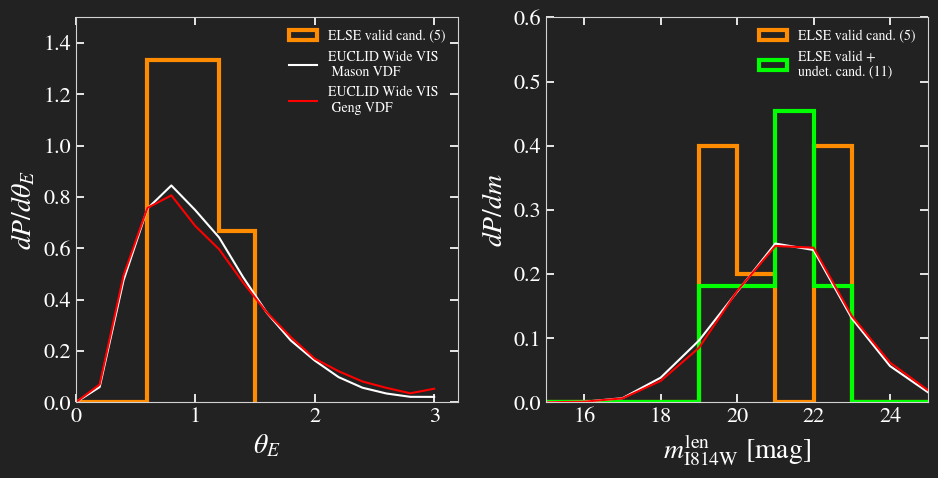

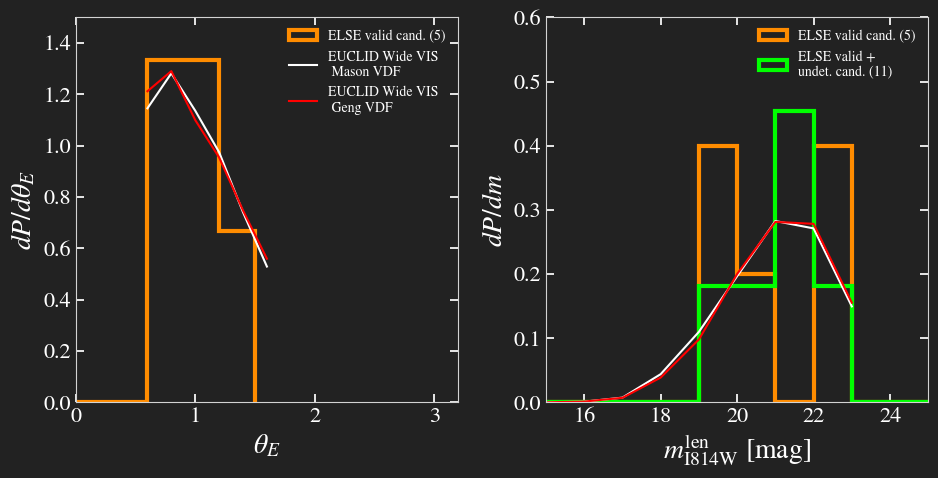

In [3]:
Euclid_ELSE_Na = np.array(['J031715+414057', 'J031741+412702', 'J031749+420011', 'J031953+415746', 'J031959+414229'])
Euclid_ELSE_Re = np.array([0.70  , 1.01  , 0.92  , 1.24  , 0.68  ])
Euclid_ELSE_Ie = np.array([20.810, 22.393, 19.791, 19.576, 22.467])
Euclid_udet_Ie = np.array([21.651, 21.902, 21.193, 21.171, 21.280, 20.905])

line_c, cmap_c, _col_, col_A, col_B, col_C, col_D, fn_prefix = lens_plot.set_plt_param(PLOT_FOR_KEYNOTE)
ccc = 'w' if PLOT_FOR_KEYNOTE else 'k'
cc2 = 'r'
if PLOT_FOR_KEYNOTE:
    ER_col1, ER_col2, ER_col3, ER_col4, _ALPHA_  = 'darkorange', 'lime', 'magenta', 'cyan', 1
else:
    ER_col1, ER_col2, ER_col3, ER_col4, _ALPHA_  = 'forestgreen', 'teal', 'orange', 'firebrick', 1
line_thick = 3
_nbins_Re = np.histogram_bin_edges(Euclid_ELSE_Re, bins='fd', range=(0, 1.5))
# m_obs = np.histogram_bin_edges(Euclid_ELSE_Ie, bins='fd', range=(19, 23))
m_obs = np.linspace(15, 25, 11)

fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=False, sharey=False)
plt.subplots_adjust(wspace=.23, hspace=.2)
ax[0].hist(Euclid_ELSE_Re, bins=_nbins_Re, density=True, histtype='step', color=ER_col1,
    lw=line_thick, alpha=_ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Re)})')
ax[1].hist(Euclid_ELSE_Ie, bins=m_obs, density=True, histtype='step', lw = line_thick, color=ER_col1,
            alpha = _ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Ie)})')
ax[1].hist(np.append(Euclid_ELSE_Ie,Euclid_udet_Ie),
           bins=m_obs, density=True, histtype='step', lw = line_thick, color=ER_col2,
           alpha = _ALPHA_, label=f'ELSE valid +\nundet. cand. ({len(Euclid_ELSE_Ie) + len(Euclid_udet_Ie)})')
SMOOTH = 1
title = 'EUCLID Wide VIS'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
ax[0].plot(Rein_array, P_Rein, c=ccc, ls='-', label='EUCLID Wide VIS\n Mason VDF')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
norm = integrate.simps(m_lens, m_obs)
ax[1].plot(m_obs, m_lens/norm, color=ccc)

title = 'EUCLID Wide VIS VDF Geng'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
ax[0].plot(Rein_array, P_Rein, c=cc2, ls='-', label='EUCLID Wide VIS\n Geng VDF')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
norm = integrate.simps(m_lens, m_obs)
ax[1].plot(m_obs, m_lens/norm, color=cc2)
ax[0].set_ylim((0,1.5))
ax[0].set_ylabel(r'$dP/d\theta_E$', fontsize=20)
ax[0].set_xlabel(r'$\theta_E$', fontsize=20)
ax[0].set_xlim((0,3.2))
ax[1].set_xlabel(r'$m_\text{I814W}^\text{len}$ [mag]', fontsize=20)
ax[1].set_ylim((0,0.6))
ax[1].set_ylabel(r'$dP/dm$', fontsize=20)
ax[1].set_xlim((15,25))
ax[0].legend(fontsize=10, loc=1)
ax[1].legend(fontsize=10, loc=0)
# plt.savefig('img/ELSE.png', dpi=200, bbox_inches='tight')
plt.show()

min_Euclid_ELSE_Re = 0.6
max_Euclid_ELSE_Re = 1.6
min_Euclid_udet_Ie = 15.
max_Euclid_udet_Ie = 23.
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=False, sharey=False)
plt.subplots_adjust(wspace=.23, hspace=.2)
ax[0].hist(Euclid_ELSE_Re, bins=_nbins_Re, density=True, histtype='step', color=ER_col1,
    lw=line_thick, alpha=_ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Re)})')
ax[1].hist(Euclid_ELSE_Ie, bins=m_obs, density=True, histtype='step', lw = line_thick, color=ER_col1,
            alpha = _ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Ie)})')
ax[1].hist(np.append(Euclid_ELSE_Ie,Euclid_udet_Ie),
           bins=m_obs, density=True, histtype='step', lw = line_thick, color=ER_col2,
           alpha = _ALPHA_, label=f'ELSE valid +\nundet. cand. ({len(Euclid_ELSE_Ie) + len(Euclid_udet_Ie)})')
title = 'EUCLID Wide VIS'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
mask = np.logical_and(min_Euclid_ELSE_Re <= Rein_array,  Rein_array<= max_Euclid_ELSE_Re)
norm = integrate.simps(P_Rein[mask], Rein_array[mask])
ax[0].plot(Rein_array[mask], P_Rein[mask]/norm, c=ccc, ls='-', label='EUCLID Wide VIS\n Mason VDF')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
norm = integrate.simps(m_lens[mask], m_obs[mask])
ax[1].plot(m_obs[mask], m_lens[mask]/norm, color=ccc)

title = 'EUCLID Wide VIS VDF Geng'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
mask = np.logical_and(min_Euclid_ELSE_Re <= Rein_array,  Rein_array<= max_Euclid_ELSE_Re)
norm = integrate.simps(P_Rein[mask], Rein_array[mask])
ax[0].plot(Rein_array[mask], P_Rein[mask]/norm, c=cc2, ls='-', label='EUCLID Wide VIS\n Geng VDF')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
norm = integrate.simps(m_lens[mask], m_obs[mask])
ax[1].plot(m_obs[mask], m_lens[mask]/norm, color=cc2)
ax[0].set_ylim((0,1.5))
ax[0].set_ylabel(r'$dP/d\theta_E$', fontsize=20)
ax[0].set_xlabel(r'$\theta_E$', fontsize=20)
ax[0].set_xlim((0,3.2))
ax[1].set_xlabel(r'$m_\text{I814W}^\text{len}$ [mag]', fontsize=20)
ax[1].set_ylim((0,0.6))
ax[1].set_ylabel(r'$dP/dm$', fontsize=20)
ax[1].set_xlim((15,25))
ax[0].legend(fontsize=10, loc=1)
ax[1].legend(fontsize=10, loc=0)
# plt.savefig('img/ELSE.png', dpi=200, bbox_inches='tight')
plt.show()

In survey EUCLID Wide VIS the fraction of sources above zs>3 is P=4.7%
In survey COSMOS HST i band the fraction of sources above zs>3 is P=6.7%
FILE do NOT exist - RUNNING MODEL


100%|██████████| 50/50 [01:08<00:00,  1.37s/it]


In survey EUCLID Wide H the fraction of sources above zs>3 is P=10.2%
In survey PEARLS NEP F277W the fraction of sources above zs>3 is P=31.7%


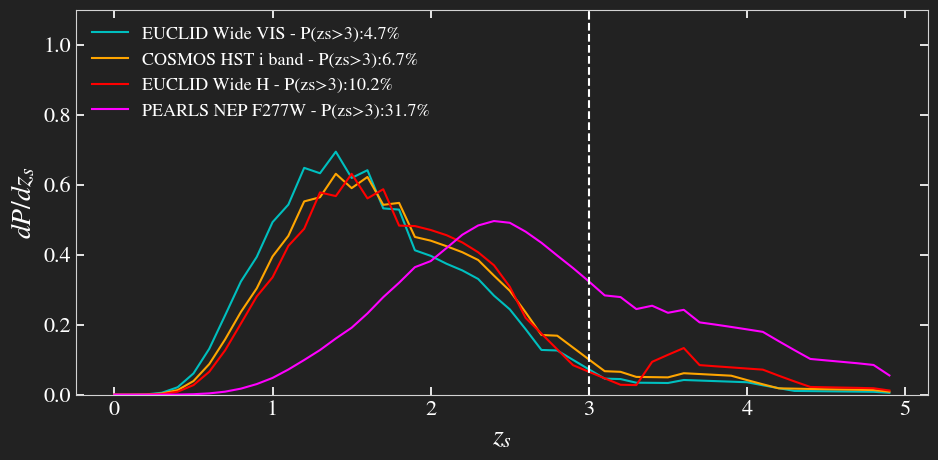

In [31]:
zs_lim  = 3
maskzs = zs_array > zs_lim
colors = ['c', 'orange', 'red', 'fuchsia']
fig, ax = plt.subplots(1, 1, figsize=(11, 5), sharex=False, sharey=False)
for title, col in zip(['EUCLID Wide VIS', 'COSMOS HST i band', 'EUCLID Wide H', 'PEARLS NEP F277W'], colors):
     Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
          get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
     f_zs = integrate.simps(P_zs[maskzs], zs_array[maskzs])/integrate.simps(P_zs, zs_array)
     print(f'In survey {title} the fraction of sources above zs>{zs_lim} is P={f_zs*100:.1f}%')
     lbl = f'{title} - P(zs>{zs_lim}):{f_zs*100:.1f}%'
     ax.plot(zs_array, P_zs, color=col, label=lbl)
ax.set_ylim((0,1.1))
ax.set_ylabel(r'$dP/dz_s$', fontsize=20)
ax.set_xlabel(r'$z_s$', fontsize=20)
ax.axvline(zs_lim, c='w', ls='--')
plt.legend()
plt.show()

In survey EUCLID Wide VIS the fraction of sources above zl>1 is P=5.3%
In survey COSMOS HST i band the fraction of sources above zl>1 is P=7.2%
In survey EUCLID Wide H the fraction of sources above zl>1 is P=6.3%
In survey PEARLS NEP F277W the fraction of sources above zl>1 is P=31.7%


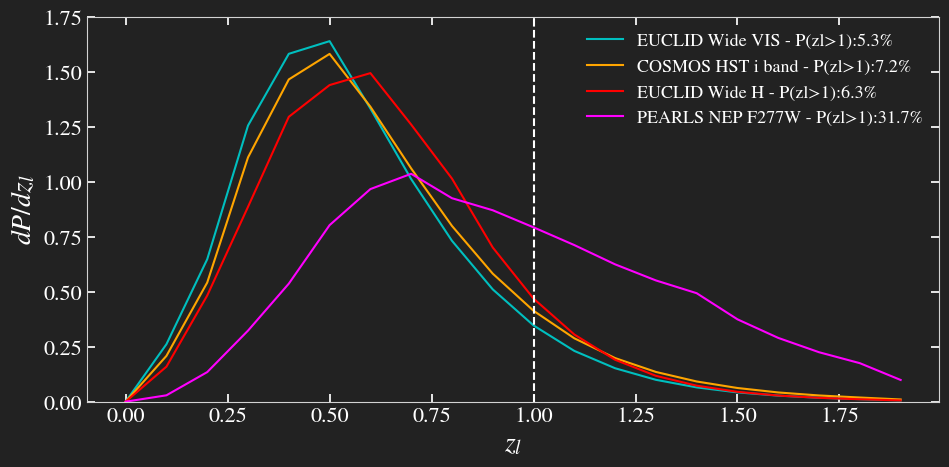

In [32]:
zl_lim  = 1
maskzl = zl_array > zl_lim
colors = ['c', 'orange', 'red', 'fuchsia']
fig, ax = plt.subplots(1, 1, figsize=(11, 5), sharex=False, sharey=False)
for title, col in zip(['EUCLID Wide VIS', 'COSMOS HST i band', 'EUCLID Wide H', 'PEARLS NEP F277W'], colors):
     Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
          get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
     f_zl = integrate.simps(P_zl[maskzl], zl_array[maskzl])/integrate.simps(P_zl, zl_array)
     print(f'In survey {title} the fraction of sources above zl>{zl_lim} is P={f_zl*100:.1f}%')
     lbl = f'{title} - P(zl>{zl_lim}):{f_zl*100:.1f}%'
     ax.plot(zl_array, P_zl, color=col, label=lbl)
ax.set_ylim((0,1.75))
ax.set_ylabel(r'$dP/dz_l$', fontsize=20)
ax.set_xlabel(r'$z_l$', fontsize=20)
ax.axvline(zl_lim, c='w', ls='--')
plt.legend()
plt.show()

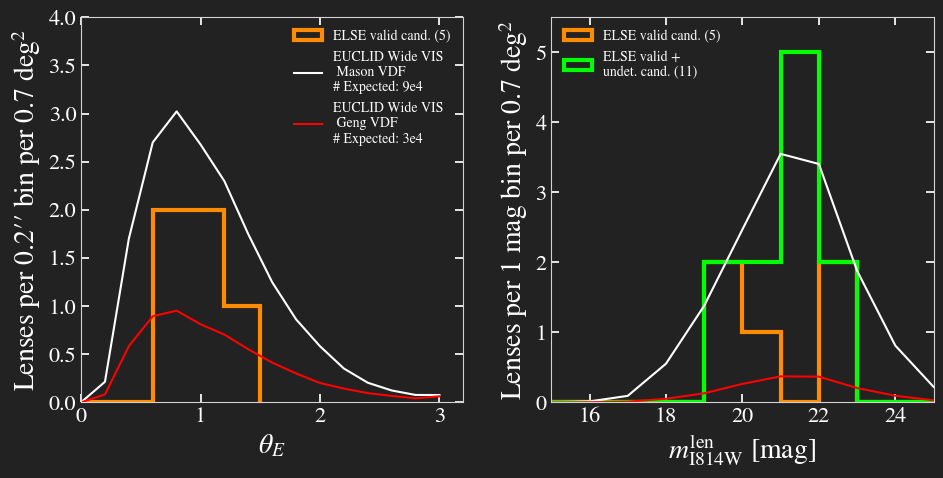

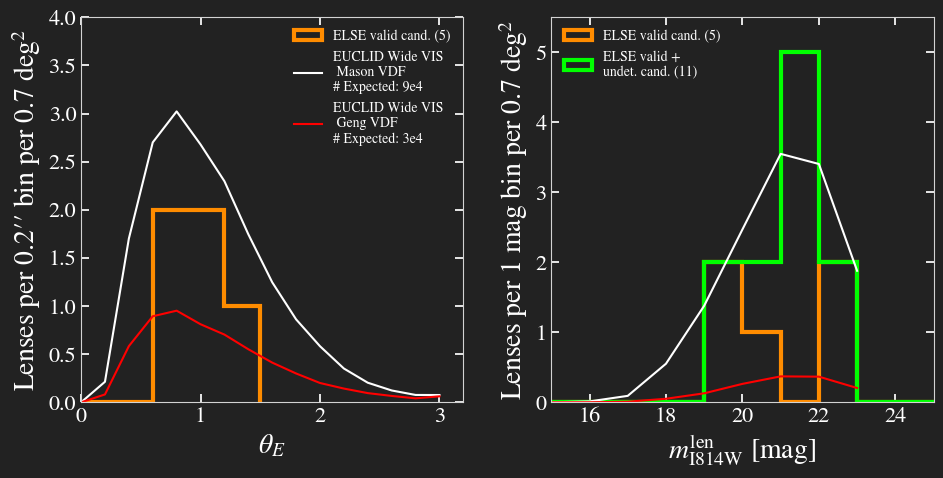

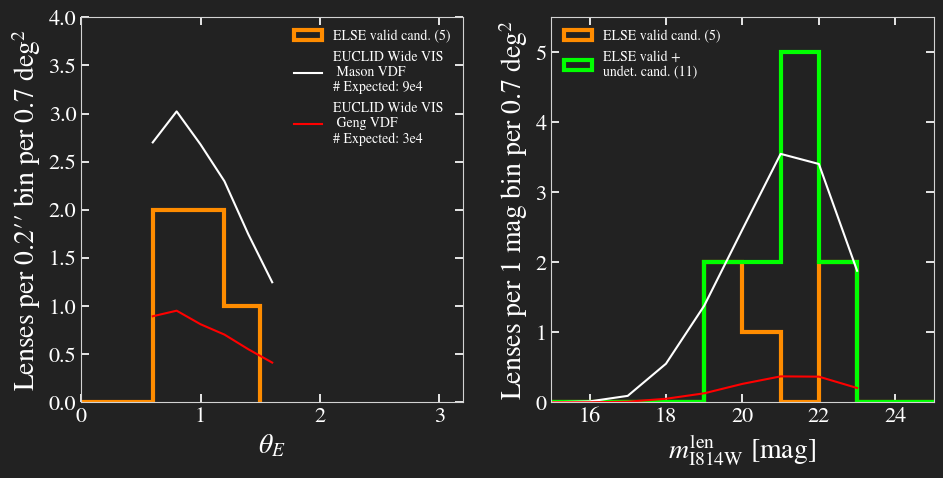

In [18]:
PERC_LOSS_BELOW_M23 = 1/(1 - 0.14)
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=False, sharey=False)
plt.subplots_adjust(wspace=.23, hspace=.2)
ax[0].hist(Euclid_ELSE_Re, bins=_nbins_Re, density=False, histtype='step', color=ER_col1,
    lw=line_thick, alpha=_ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Re)})')
ax[1].hist(Euclid_ELSE_Ie, bins=m_obs, density=False, histtype='step', lw = line_thick, color=ER_col1,
            alpha = _ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Ie)})')
ax[1].hist(np.append(Euclid_ELSE_Ie,Euclid_udet_Ie),
           bins=m_obs, density=False, histtype='step', lw = line_thick, color=ER_col2,
           alpha = _ALPHA_, label=f'ELSE valid +\nundet. cand. ({len(Euclid_ELSE_Ie) + len(Euclid_udet_Ie)})')
SMOOTH = 1
title = 'EUCLID Wide VIS'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
norm = 1/np.sum(matrix) * PERC_LOSS_BELOW_M23
ax[0].plot(Rein_array, P_Rein/norm, c=ccc, ls='-', label='EUCLID Wide VIS\n Mason VDF\n# Expected: 9e4')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
ax[1].plot(m_obs, m_lens/norm, color=ccc)

title = 'EUCLID Wide VIS VDF Geng'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
norm = 1/np.sum(matrix) * PERC_LOSS_BELOW_M23
ax[0].plot(Rein_array, P_Rein/norm, c=cc2, ls='-', label='EUCLID Wide VIS\n Geng VDF\n# Expected: 3e4')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
ax[1].plot(m_obs, m_lens/norm, color=cc2)
ax[0].set_ylim((0,4))
ax[0].set_ylabel(r'Lenses per $0.2\prime\prime$ bin per $0.7$ deg$^2$', fontsize=20)
ax[0].set_xlabel(r'$\theta_E$', fontsize=20)
ax[0].set_xlim((0,3.2))
ax[1].set_xlabel(r'$m_\text{I814W}^\text{len}$ [mag]', fontsize=20)
ax[1].set_ylim((0,5.5))
ax[1].set_ylabel(r'Lenses per $1$ mag bin per $0.7$ deg$^2$', fontsize=20)
ax[1].set_xlim((15,25))
ax[0].legend(fontsize=10, loc=1)
ax[1].legend(fontsize=10, loc=0)
# plt.savefig('img/ELSE.png', dpi=200, bbox_inches='tight')
plt.show()

min_Euclid_ELSE_Re = 0.
max_Euclid_ELSE_Re = 4.
min_Euclid_udet_Ie = 15.
max_Euclid_udet_Ie = 23.
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=False, sharey=False)
plt.subplots_adjust(wspace=.23, hspace=.2)
ax[0].hist(Euclid_ELSE_Re, bins=_nbins_Re, density=False, histtype='step', color=ER_col1,
    lw=line_thick, alpha=_ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Re)})')
ax[1].hist(Euclid_ELSE_Ie, bins=m_obs, density=False, histtype='step', lw = line_thick, color=ER_col1,
            alpha = _ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Ie)})')
ax[1].hist(np.append(Euclid_ELSE_Ie,Euclid_udet_Ie),
           bins=m_obs, density=False, histtype='step', lw = line_thick, color=ER_col2,
           alpha = _ALPHA_, label=f'ELSE valid +\nundet. cand. ({len(Euclid_ELSE_Ie) + len(Euclid_udet_Ie)})')
title = 'EUCLID Wide VIS'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
mask = np.logical_and(min_Euclid_ELSE_Re <= Rein_array,  Rein_array<= max_Euclid_ELSE_Re)
norm = 1/np.sum(matrix) * PERC_LOSS_BELOW_M23
ax[0].plot(Rein_array[mask], P_Rein[mask]/norm, c=ccc, ls='-', label='EUCLID Wide VIS\n Mason VDF\n# Expected: 9e4')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
ax[1].plot(m_obs[mask], m_lens[mask]/norm, color=ccc)

title = 'EUCLID Wide VIS VDF Geng'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
mask = np.logical_and(min_Euclid_ELSE_Re <= Rein_array,  Rein_array<= max_Euclid_ELSE_Re)
norm = 1/np.sum(matrix) * PERC_LOSS_BELOW_M23
ax[0].plot(Rein_array[mask], P_Rein[mask]/norm, c=cc2, ls='-', label='EUCLID Wide VIS\n Geng VDF\n# Expected: 3e4')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
ax[1].plot(m_obs[mask], m_lens[mask]/norm, color=cc2)
ax[0].set_ylim((0,4))
ax[0].set_ylabel(r'Lenses per $0.2\prime\prime$ bin per $0.7$ deg$^2$', fontsize=20)
ax[0].set_xlabel(r'$\theta_E$', fontsize=20)
ax[0].set_xlim((0,3.2))
ax[1].set_xlabel(r'$m_\text{I814W}^\text{len}$ [mag]', fontsize=20)
ax[1].set_ylim((0,5.5))
ax[1].set_ylabel(r'Lenses per $1$ mag bin per $0.7$ deg$^2$', fontsize=20)
ax[1].set_xlim((15,25))
ax[0].legend(fontsize=10, loc=1)
ax[1].legend(fontsize=10, loc=0)
# plt.savefig('img/ELSE.png', dpi=200, bbox_inches='tight')
plt.show()

min_Euclid_ELSE_Re = 0.6
max_Euclid_ELSE_Re = 1.6
min_Euclid_udet_Ie = 15.
max_Euclid_udet_Ie = 23.
fig, ax = plt.subplots(1, 2, figsize=(11, 5), sharex=False, sharey=False)
plt.subplots_adjust(wspace=.23, hspace=.2)
ax[0].hist(Euclid_ELSE_Re, bins=_nbins_Re, density=False, histtype='step', color=ER_col1,
    lw=line_thick, alpha=_ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Re)})')
ax[1].hist(Euclid_ELSE_Ie, bins=m_obs, density=False, histtype='step', lw = line_thick, color=ER_col1,
            alpha = _ALPHA_, label=f'ELSE valid cand. ({len(Euclid_ELSE_Ie)})')
ax[1].hist(np.append(Euclid_ELSE_Ie,Euclid_udet_Ie),
           bins=m_obs, density=False, histtype='step', lw = line_thick, color=ER_col2,
           alpha = _ALPHA_, label=f'ELSE valid +\nundet. cand. ({len(Euclid_ELSE_Ie) + len(Euclid_udet_Ie)})')
title = 'EUCLID Wide VIS'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
mask = np.logical_and(min_Euclid_ELSE_Re <= Rein_array,  Rein_array<= max_Euclid_ELSE_Re)
norm = 1/np.sum(matrix) * PERC_LOSS_BELOW_M23
ax[0].plot(Rein_array[mask], P_Rein[mask]/norm, c=ccc, ls='-', label='EUCLID Wide VIS\n Mason VDF\n# Expected: 9e4')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
ax[1].plot(m_obs[mask], m_lens[mask]/norm, color=ccc)

title = 'EUCLID Wide VIS VDF Geng'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
mask = np.logical_and(min_Euclid_ELSE_Re <= Rein_array,  Rein_array<= max_Euclid_ELSE_Re)
norm = 1/np.sum(matrix) * PERC_LOSS_BELOW_M23
ax[0].plot(Rein_array[mask], P_Rein[mask]/norm, c=cc2, ls='-', label='EUCLID Wide VIS\n Geng VDF\n# Expected: 3e4')
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
ax[1].plot(m_obs[mask], m_lens[mask]/norm, color=cc2)
ax[0].set_ylim((0,4))
ax[0].set_ylabel(r'Lenses per $0.2\prime\prime$ bin per $0.7$ deg$^2$', fontsize=20)
ax[0].set_xlabel(r'$\theta_E$', fontsize=20)
ax[0].set_xlim((0,3.2))
ax[1].set_xlabel(r'$m_\text{I814W}^\text{len}$ [mag]', fontsize=20)
ax[1].set_ylim((0,5.5))
ax[1].set_ylabel(r'Lenses per $1$ mag bin per $0.7$ deg$^2$', fontsize=20)
ax[1].set_xlim((15,25))
ax[0].legend(fontsize=10, loc=1)
ax[1].legend(fontsize=10, loc=0)
# plt.savefig('img/ELSE.png', dpi=200, bbox_inches='tight')
plt.show()

In [5]:
min_Euclid_udet_Ie = 15.
max_Euclid_udet_Ie = 23.
title = 'EUCLID Wide VIS VDF Geng'
Ngal_zs_zl, Ngal_zl_Rein, Ngal_Rein_zs, P_zs, P_zl, P_Rein, matrix =\
     get_contours(title, zl_array, zs_array, sigma_array, Rein_array, KDE=False)
m_lens = ls.get_len_magnitude_distr(m_obs, zl_array, sigma_array, matrix, obs_band = 'sdss_i0')
m_lens = m_lens/integrate.simps(m_lens, m_obs)
mask = np.logical_and(min_Euclid_udet_Ie <= m_obs,  m_obs<= max_Euclid_udet_Ie)
np.sum(m_lens)*np.diff(m_obs)[0], np.sum(m_lens[mask])*np.diff(m_obs)[0]

(0.9985612622857116, 0.9181382795384265)

In [ ]:
ls